In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, recall_score, accuracy_score, precision_score, f1_score,classification_report,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, auc


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
os.getcwd()

'/home/euphrates/Desktop/dreps/DS/Radiomics/Boun-radiomics/notebooks/denemedosyasi/ozyegin-1/ozyegin'

In [5]:
os.listdir("CSV")

['rcc2.csv',
 'rcc1.csv',
 'test2.csv',
 'originalitself.csv',
 'flippedOriginal.csv',
 'phase_reg_key.csv',
 'test1.csv',
 'dilatedResized.csv',
 'erodedOriginal.csv',
 'dilatedOriginal.csv',
 'resizeditself.csv',
 'erodedResized.csv',
 'flippedResized.csv']

###  UCSF  --arterial  -- aml

In [6]:
reg = pd.read_csv('CSV/phase_reg_key.csv')


In [7]:
reg.columns

Index(['pid', 'noncon', 'arterial', 'delay', 'portven', 'mask',
       'ct_manufacturer', 'patient_age_years', 'patient_sex', 'pathology',
       'tumor_type', 'pathology_grade', 'tumor_laterality', 'tumor_size_cm',
       'tumor_biopsy_type'],
      dtype='object')

In [8]:

reg[(reg['tumor_type'].isin(['angiomyolipoma']))or(reg['pathology'].isin(['angiomyolipoma']))]

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
reg[reg['tumor_type'].isin(['angiomyolipoma'])][["pid",'tumor_type','pathology']]

In [ ]:
reg[reg['tumor_type'].isin(['angiomyolipoma'])][["pid",'tumor_type','pathology']].shape

In [9]:
os.listdir("/media/euphrates/DS-Backup/angiomyolipoma/ucsf-rmac-dataset")

FileNotFoundError: [WinError 3] Sistem belirtilen yolu bulamıyor: '/media/euphrates/DS-Backup/angiomyolipoma/ucsf-rmac-dataset'

In [ ]:
[i for i in reg[reg['pathology'].isin(['angiomyolipoma'])].pid if i not in [i.split('.')[0] for i in os.listdir("/media/euphrates/DS-Backup/angiomyolipoma/ucsf-rmac-dataset")]]

In [10]:
[i.split('.')[0] for i in os.listdir("/media/euphrates/DS-Backup/angiomyolipoma/ucsf-rmac-dataset")]

FileNotFoundError: [WinError 3] Sistem belirtilen yolu bulamıyor: '/media/euphrates/DS-Backup/angiomyolipoma/ucsf-rmac-dataset'

In [11]:
'dkp1S2CrhL' in [i.split('.')[0] for i in os.listdir("/media/euphrates/DS-Backup/angiomyolipoma/ucsf-rmac-dataset")]

FileNotFoundError: [WinError 3] Sistem belirtilen yolu bulamıyor: '/media/euphrates/DS-Backup/angiomyolipoma/ucsf-rmac-dataset'

In [6]:
dd1= pd.read_csv('CSV/dilatedOriginal.csv')

In [7]:
dd1.shape

(8, 1180)

In [8]:
dd1['augmentation'] = 'dilated'
dd1['source_subset'] = 'Original'


In [9]:
pd.set_option("display.max_rows",1500)

In [10]:
dd1.iloc[1,:].to_dict().items()

dict_items([('PID', '45Nh52EJwK'), ('label', 'Unknown'), ('tumor_type', 2.0), ('pathology', 'angiomyolipoma'), ('pathology_grade', nan), ('Patient_Age', '058Y'), ('Patient_Sex', 'F'), ('Manufacturer', 'GE MEDICAL SYSTEMS LightSpeed VCT'), ('phase', 'arterial'), ('ct_spacing_mm', '[0.8183590173721313, 0.8183590173721313, 2.5]'), ('mask_spacing_mm', '[0.8183590173721313, 0.8183590173721313, 2.5]'), ('ct_shape', '[512, 512, 104]'), ('mask_voxel_count', 51331), ('original_shape_Elongation', 0.8780464769296084), ('original_shape_Flatness', 0.6951523973900751), ('original_shape_LeastAxisLength', 40.83170403922956), ('original_shape_MajorAxisLength', 58.73777346166213), ('original_shape_Maximum2DDiameterColumn', 66.40030120413611), ('original_shape_Maximum2DDiameterRow', 58.83026432033091), ('original_shape_Maximum2DDiameterSlice', 65.85590330410783), ('original_shape_Maximum3DDiameter', 73.62744053679987), ('original_shape_MeshVolume', 85475.875), ('original_shape_MinorAxisLength', 51.574495

In [11]:
dd2= pd.read_csv('CSV/dilatedResized.csv')

In [12]:
dd2.shape

(3, 1180)

In [13]:
dd2['augmentation'] = 'dilated'
dd2['source_subset'] = 'Resized'

In [14]:
df1= pd.read_csv('CSV/flippedOriginal.csv')

In [15]:
df1.shape

(8, 1180)

In [16]:
df1['augmentation'] = 'flipped'
df1['source_subset'] = 'Original'

In [17]:
df2 = pd.read_csv('CSV/flippedResized.csv')

In [18]:
df2.shape

(3, 1180)

In [19]:
df2['augmentation'] = 'flipped'
df2['source_subset'] = 'Resized'

In [20]:
de1 = pd.read_csv('CSV/erodedOriginal.csv')

In [21]:
de1.shape

(8, 1180)

In [22]:
de1['augmentation'] = 'eroded'
de1['source_subset'] = 'Original'

In [23]:
de2 = pd.read_csv('CSV/erodedResized.csv')

In [24]:
de2.shape

(3, 1180)

In [25]:
de2['augmentation'] = 'eroded'
de2['source_subset'] = 'Resized'

In [26]:
do = pd.read_csv('CSV/originalitself.csv')

In [27]:
do.shape

(8, 1180)

In [28]:
do['augmentation'] = 'NOT'
do['source_subset'] = 'Original'

In [29]:
dr = pd.read_csv('CSV/resizeditself.csv')

In [30]:
dr.shape

(3, 1180)

In [31]:
dr['augmentation'] = 'NOT'
dr['source_subset'] = 'Resized'

In [32]:
drcc1 = pd.read_csv('CSV/rcc1.csv')
drcc1.shape

(23, 1180)

In [33]:
drcc1['augmentation'] = 'NOT'
drcc1['source_subset'] = 'Original-RCC'

In [34]:
drcc2 = pd.read_csv('CSV/rcc2.csv')

In [35]:
drcc2.shape

(35, 1180)

In [36]:
drcc2['augmentation'] = 'NOT'
drcc2['source_subset'] = 'Original-RCC'

In [37]:
dfA= pd.concat([dd1,dd2,df1,df2,de1,de2,do,dr], axis = 0, ignore_index= 1)

In [38]:
dfA.shape

(44, 1182)

In [39]:
dfA['target'] = 1

In [40]:
dfR = pd.concat([drcc1,drcc2], axis = 0, ignore_index= 1)

In [41]:
dfR.shape

(58, 1182)

In [42]:
dfR['target'] = 0

In [43]:
dfA.columns

Index(['PID', 'label', 'tumor_type', 'pathology', 'pathology_grade',
       'Patient_Age', 'Patient_Sex', 'Manufacturer', 'phase', 'ct_spacing_mm',
       ...
       'diagnostics_Mask-interpolated_VoxelNum',
       'diagnostics_Mask-interpolated_VolumeNum',
       'diagnostics_Mask-interpolated_CenterOfMassIndex',
       'diagnostics_Mask-interpolated_CenterOfMass',
       'diagnostics_Mask-interpolated_Mean',
       'diagnostics_Mask-interpolated_Minimum',
       'diagnostics_Mask-interpolated_Maximum', 'augmentation',
       'source_subset', 'target'],
      dtype='object', length=1183)

In [44]:
dfRS = dfR.sample(44)

In [45]:
dfRS.index

Index([49, 50, 39, 26, 12, 15, 16, 17, 40, 38, 21, 33, 35, 37, 41, 18,  9, 10,
       34, 42, 13, 36, 43,  8, 14,  1, 51, 11,  3, 52,  4, 47, 24,  5,  7,  2,
       22, 32, 23, 30, 19, 56, 44, 20],
      dtype='int64')

23 Component

Index([25, 40,  3, 53, 11, 49, 51, 54, 52, 34, 23, 10, 21,  0, 19, 43, 33,  7,
        9, 47,  5, 46, 29, 41, 44, 20,  4, 36, 14, 57, 17, 24, 28, 37,  6,  2,
       38, 45, 48, 12, 27, 39, 56, 26],
      dtype='int64')

['5VcthT0eZp',
 'Xr9i2bphzA',
 '7I8VYuMftc',
 'uDgXxF1ila',
 'Iswe2OQvvA',
 'rHrX0BpUcX',
 'tWHXsbhqIm',
 'ubDnfl6DDg',
 'tX93r2Wx5X',
 'QcyodOs3Q5',
 '475HQrHo5Y',
 'IjFflm1TPw',
 'gN54OjVPDG',
 '58tEvb2lRX',
 'aiMWXsF8Vr',
 'fUuItGkARL',
 'QNDAa9SoJ7',
 'DcvE7Qbk7u',
 'FamKf6j9Ly',
 'mpR4Lkg6WJ',
 'ALZseu8axq',
 'kuLnglAoYW',
 'ByY2Oz0f16',
 'ZJqn6Mcg6s',
 'fvHwwVjeqZ',
 'fFUuqn2Cdh',
 '7WV4qCLwpN',
 'U12PW8VufV',
 'QPHEXsfL0J',
 'zmwtNTDvF2',
 'X910IACtaz',
 '5OjuFGw7YB',
 'BRvha4ynJQ',
 'VyIRlglwu4',
 'CSgNAkMSUq',
 '6S3AR8Qv8n',
 'VzNDxCT8fa',
 'kQCfJp5tkL',
 'pWfvOWoiHg',
 'L7exPPUF3N',
 'B3uXUCxmk3',
 'WC3J7Q0yat',
 'xStGbIsHhB',
 '9zuctMrDLy']

In [546]:
dfRS.PID.to_list()

['5VcthT0eZp',
 'Xr9i2bphzA',
 '7I8VYuMftc',
 'uDgXxF1ila',
 'Iswe2OQvvA',
 'rHrX0BpUcX',
 'tWHXsbhqIm',
 'ubDnfl6DDg',
 'tX93r2Wx5X',
 'QcyodOs3Q5',
 '475HQrHo5Y',
 'IjFflm1TPw',
 'gN54OjVPDG',
 '58tEvb2lRX',
 'aiMWXsF8Vr',
 'fUuItGkARL',
 'QNDAa9SoJ7',
 'DcvE7Qbk7u',
 'FamKf6j9Ly',
 'mpR4Lkg6WJ',
 'ALZseu8axq',
 'kuLnglAoYW',
 'ByY2Oz0f16',
 'ZJqn6Mcg6s',
 'fvHwwVjeqZ',
 'fFUuqn2Cdh',
 '7WV4qCLwpN',
 'U12PW8VufV',
 'QPHEXsfL0J',
 'zmwtNTDvF2',
 'X910IACtaz',
 '5OjuFGw7YB',
 'BRvha4ynJQ',
 'VyIRlglwu4',
 'CSgNAkMSUq',
 '6S3AR8Qv8n',
 'VzNDxCT8fa',
 'kQCfJp5tkL',
 'pWfvOWoiHg',
 'L7exPPUF3N',
 'B3uXUCxmk3',
 'WC3J7Q0yat',
 'xStGbIsHhB',
 '9zuctMrDLy']

In [46]:
dfU = pd.concat([dfA,dfRS], axis = 0, ignore_index= 1)

In [47]:
dfU.drop('pathology_grade', axis =1, inplace= True)

In [48]:
dfU['case_id'] = dfU.PID

In [49]:
y = dfU['target']

In [50]:
df_backup = dfU[['case_id','augmentation','source_subset','target']]

In [51]:
df_backup.sample(10)

,case_id,augmentation,source_subset,target
30,JMfIEEWlAz,eroded,Resized,1
69,5CZeU5xT7S,NOT,Original-RCC,0
74,7WV4qCLwpN,NOT,Original-RCC,0
19,JMfIEEWlAz,flipped,Resized,1
61,IjFflm1TPw,NOT,Original-RCC,0
77,ALZseu8axq,NOT,Original-RCC,0
46,WC3J7Q0yat,NOT,Original-RCC,0
55,QNDAa9SoJ7,NOT,Original-RCC,0
5,pXwitKy0oU,dilated,Original,1
78,DcvE7Qbk7u,NOT,Original-RCC,0


In [52]:
dfU.isnull().sum()

PID                                      0
label                                    0
tumor_type                               0
pathology                                0
Patient_Age                              0
                                        ..
diagnostics_Mask-interpolated_Maximum    0
augmentation                             0
source_subset                            0
target                                   0
case_id                                  0
Length: 1183, dtype: int64

In [53]:
dfU.select_dtypes(include='object').groupby('Manufacturer')['Manufacturer'].count()

Manufacturer
GE MEDICAL SYSTEMS Discovery CT750 HD    10
GE MEDICAL SYSTEMS GENESIS_ZEUS           1
GE MEDICAL SYSTEMS HiSpeed CT/i           4
GE MEDICAL SYSTEMS LightSpeed Pro 16      1
GE MEDICAL SYSTEMS LightSpeed Ultra       4
GE MEDICAL SYSTEMS LightSpeed VCT        20
GE MEDICAL SYSTEMS LightSpeed16           7
GE MEDICAL SYSTEMS Optima CT660           6
Philips Brilliance 64                     2
Philips Mx8000 IDT                        1
Philips Mx8000 IDT 16                     7
SIEMENS Biograph 64                       1
SIEMENS SOMATOM Definition AS             2
SIEMENS SOMATOM Definition AS+            3
SIEMENS SOMATOM Definition Flash          1
SIEMENS Sensation 16                      2
SIEMENS Sensation 40                      4
SIEMENS Sensation 64                      2
TOSHIBA Aquilion                         10
Name: Manufacturer, dtype: int64

(array([-200.,    0.,  200.,  400.,  600.,  800., 1000., 1200., 1400.]),
 [Text(-200.0, 0, 'wavelet-HHH_firstorder_10Percentile'),
  Text(0.0, 0, 'tumor_type'),
  Text(200.0, 0, 'log-sigma-1-0-mm-3D_ngtdm_Contrast'),
  Text(400.0, 0, 'wavelet-LLH_firstorder_RobustMeanAbsoluteDeviation'),
  Text(600.0, 0, 'wavelet-LHH_glcm_DifferenceVariance'),
  Text(800.0, 0, 'wavelet-HLH_glcm_SumEntropy'),
  Text(1000.0, 0, 'wavelet-HHH_glrlm_RunVariance'),
  Text(1200.0, 0, ''),
  Text(1400.0, 0, '')])

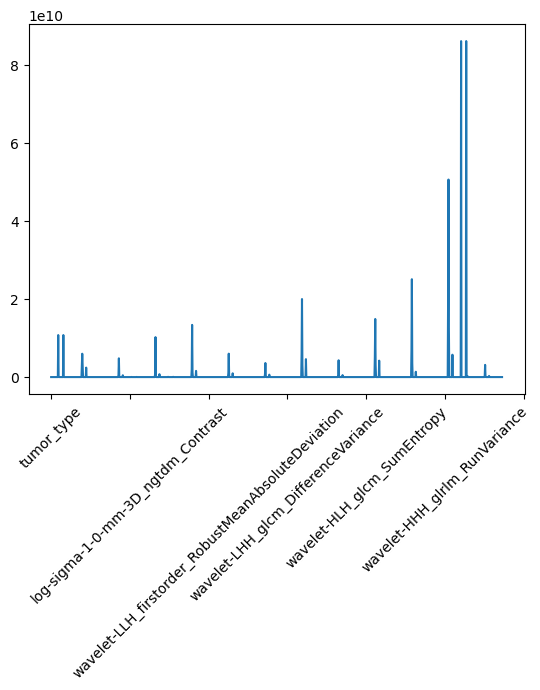

In [54]:
dfU.groupby('Manufacturer')[dfU.select_dtypes(exclude='object').columns].mean().sum().plot.line()
plt.xticks(rotation = 45)

In [477]:

from sklearn.decomposition import PCA

In [478]:
dfU.select_dtypes(exclude = "object").shape

(88, 1146)

In [479]:
dfU.drop(columns=['case_id','augmentation','source_subset','target'],axis=1).select_dtypes(exclude = "object").shape

(88, 1145)

In [480]:
df_pca = dfU.drop(['case_id','augmentation','source_subset','target','tumor_type'],axis=1).select_dtypes(exclude = "object")

In [481]:
df_pca.shape

(88, 1144)

In [482]:
sc = StandardScaler()

In [483]:
scaled_df_pca = sc.fit_transform(df_pca)

In [484]:
pc = PCA().fit(scaled_df_pca)

In [485]:
len(pc.explained_variance_ratio_)

88

Text(0, 0.5, 'Variance Ratio')

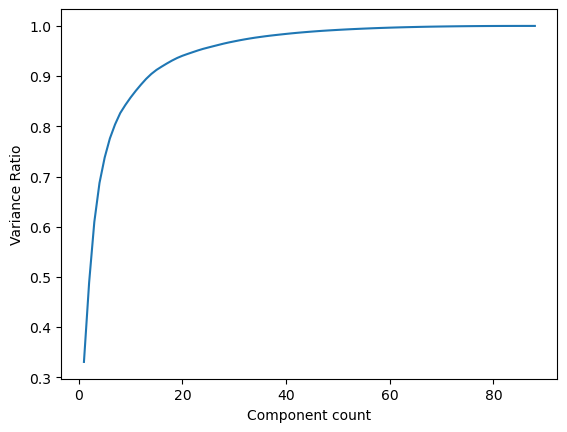

In [486]:
x = range(1,89)
plt.plot(x, np.cumsum(pc.explained_variance_ratio_),)
plt.xlabel("Component count")
plt.ylabel("Variance Ratio")

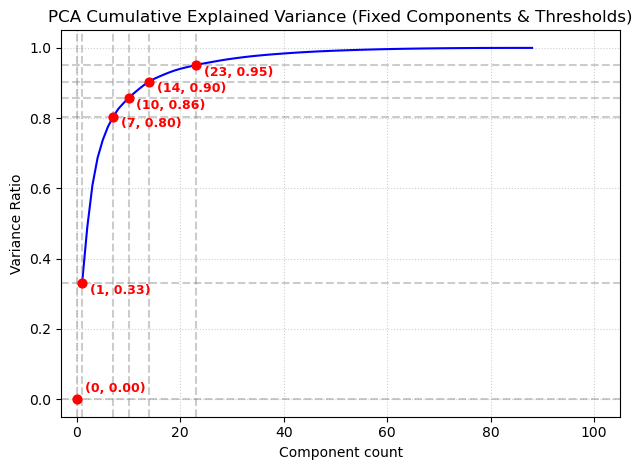

In [487]:
import numpy as np
import matplotlib.pyplot as plt

# Your original setup
x = range(1, 89)
cum_sum = np.cumsum(pc.explained_variance_ratio_)

# Create the base plot
plt.plot(x, cum_sum, color='blue', label='Cumulative Variance')
plt.xlabel("Component count")
plt.ylabel("Variance Ratio")

# Keep a set of coordinates to avoid duplicate labels if thresholds and components overlap
processed_points = set()

# --- 1. Process specific component counts ---
target_components = [0, 1, 10]

for c in target_components:
    if c == 0:
        comp_count, actual_val = 0, 0.0
    elif c in x:
        idx = list(x).index(c)
        comp_count, actual_val = c, cum_sum[idx]
    else:
        continue
    processed_points.add((comp_count, actual_val))

# --- 2. Process threshold variables from the former code ---
thresholds = [0.80, 0.90, 0.95]

for t in thresholds:
    under_threshold_indices = np.where(cum_sum >= t)[0]
    if len(under_threshold_indices) > 0:
        idx = under_threshold_indices[0]
        comp_count, actual_val = x[idx], cum_sum[idx]
        processed_points.add((comp_count, actual_val))

# --- 3. Plot and Annotate all unique critical points ---
for comp_count, actual_val in sorted(processed_points):
    # Plot a red dot on the critical point
    plt.scatter(comp_count, actual_val, color='red', s=40, zorder=5)
    
    # Draw dashed guide lines to the axes
    plt.axvline(x=comp_count, color='gray', linestyle='--', alpha=0.4)
    plt.axhline(y=actual_val, color='gray', linestyle='--', alpha=0.4)
    
    # Dynamic text positioning: if it's near (0,0), push text up. Otherwise, push it down.
    y_offset = 0.02 if actual_val < 0.1 else -0.03
    
    # Display the exact axis numbers next to the point
    plt.text(comp_count + 1.5, actual_val + y_offset, f"({comp_count}, {actual_val:.2f})", 
             fontsize=9, color='red', weight='bold')

plt.title("PCA Cumulative Explained Variance (Fixed Components & Thresholds)")
plt.grid(True, linestyle=':', alpha=0.6)

# Provide some breathing room on the canvas edges for the labels
plt.xlim(-3, 105)
plt.ylim(-0.05, 1.05)

plt.tight_layout()

# Save or display the plot
plt.savefig("explained_variance_plot.png")

In [491]:
scaled_df_pca.shape

(88, 1144)

In [492]:
pca = PCA(n_components=23)

In [493]:
scaled_df_pca.shape

(88, 1144)

In [494]:
p_scaled = pca.fit_transform(scaled_df_pca)

In [495]:
p_scaled

array([[-15.89787076,   5.36572377,   6.68807866, ...,  -0.90963541,
          1.40025281,   0.54257441],
       [ -6.86277869,  -0.78579266,   7.97079775, ...,   0.40373071,
          0.874532  ,   0.33687405],
       [ -4.07334153,  -4.79038541,  19.25510228, ...,  -0.07455778,
          1.82643637,  -2.90393135],
       ...,
       [ -0.4637616 ,   2.56357578,  12.55687927, ...,  -2.13609226,
         -1.07826956,   0.8057429 ],
       [-20.01316337,   1.17844048,  18.76819607, ...,   4.6597253 ,
          4.43381166,  -3.96612536],
       [ -0.65167734,   3.42944735,  -9.52168936, ...,   2.33628762,
          1.924806  ,  -0.27779808]])

In [496]:
X = p_scaled

In [497]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.1, random_state= 43 )

In [498]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

### SVM

In [499]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf')

In [500]:
svc.fit(X_train,y_train)

SVC()

In [501]:
y_pred = svc.predict(X_test)

In [502]:
y_pred

array([0, 0, 0, 0, 0, 1, 1, 0, 0])

In [503]:
y_test

46    0
57    0
2     1
79    0
82    0
54    0
13    1
5     1
69    0
Name: target, dtype: int64

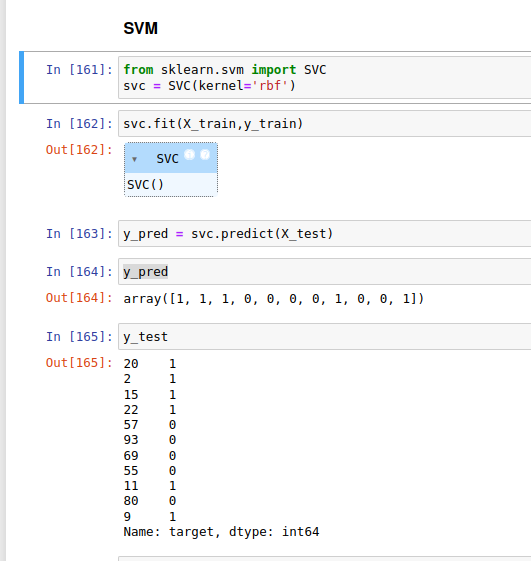

In [504]:
a = dfU.loc[y_test.index,['case_id','augmentation','source_subset','target']]

In [505]:
a

,case_id,augmentation,source_subset,target
46,7I8VYuMftc,NOT,Original-RCC,0
57,58tEvb2lRX,NOT,Original-RCC,0
2,STimK6AjK1,dilated,Original,1
79,6S3AR8Qv8n,NOT,Original-RCC,0
82,pWfvOWoiHg,NOT,Original-RCC,0
54,475HQrHo5Y,NOT,Original-RCC,0
13,STimK6AjK1,flipped,Original,1
5,pXwitKy0oU,dilated,Original,1
69,fFUuqn2Cdh,NOT,Original-RCC,0


In [506]:
a['predict'] = y_pred

In [507]:
a

,case_id,augmentation,source_subset,target,predict
46,7I8VYuMftc,NOT,Original-RCC,0,0
57,58tEvb2lRX,NOT,Original-RCC,0,0
2,STimK6AjK1,dilated,Original,1,0
79,6S3AR8Qv8n,NOT,Original-RCC,0,0
82,pWfvOWoiHg,NOT,Original-RCC,0,0
54,475HQrHo5Y,NOT,Original-RCC,0,1
13,STimK6AjK1,flipped,Original,1,1
5,pXwitKy0oU,dilated,Original,1,0
69,fFUuqn2Cdh,NOT,Original-RCC,0,0


In [508]:
eval_metric(svc, X_train, y_train, X_test, y_test)

Test_Set
[[5 1]
 [2 1]]
              precision    recall  f1-score   support

           0       0.71      0.83      0.77         6
           1       0.50      0.33      0.40         3

    accuracy                           0.67         9
   macro avg       0.61      0.58      0.58         9
weighted avg       0.64      0.67      0.65         9


Train_Set
[[30  8]
 [ 1 40]]
              precision    recall  f1-score   support

           0       0.97      0.79      0.87        38
           1       0.83      0.98      0.90        41

    accuracy                           0.89        79
   macro avg       0.90      0.88      0.88        79
weighted avg       0.90      0.89      0.88        79



In [509]:
from sklearn.metrics import RocCurveDisplay,PrecisionRecallDisplay,ConfusionMatrixDisplay

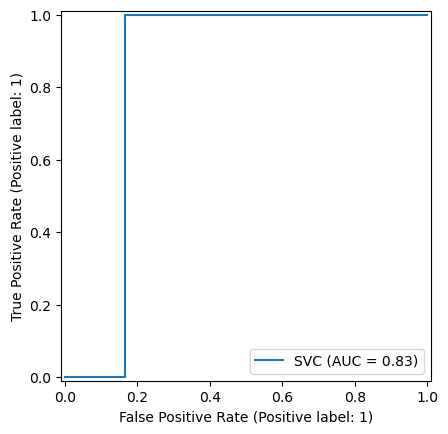

In [510]:
RocCurveDisplay.from_estimator(svc,X_test,y_test)
plt.show()

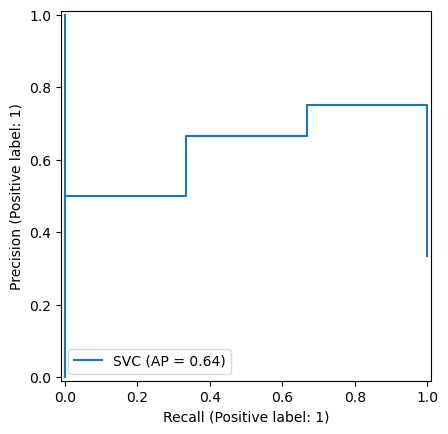

In [511]:
PrecisionRecallDisplay.from_estimator(svc,X_test,y_test)
plt.show()

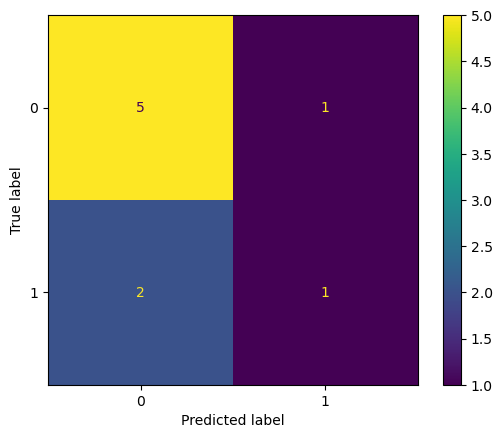

In [512]:
ConfusionMatrixDisplay.from_estimator(svc,X_test,y_test)
plt.show()

### XGBoost

In [513]:
from xgboost import XGBClassifier
xg = XGBClassifier()

In [514]:
xg.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [515]:
y_pred = xg.predict(X_test)

In [516]:
eval_metric(xg,X_train,y_train,X_test,y_test)

Test_Set
[[5 1]
 [1 2]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.67      0.67      0.67         3

    accuracy                           0.78         9
   macro avg       0.75      0.75      0.75         9
weighted avg       0.78      0.78      0.78         9


Train_Set
[[38  0]
 [ 0 41]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        41

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



In [517]:
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
import matplotlib.pyplot as plt 


In [518]:
cm = confusion_matrix(y_test,y_pred)

In [519]:
cm

array([[5, 1],
       [1, 2]])

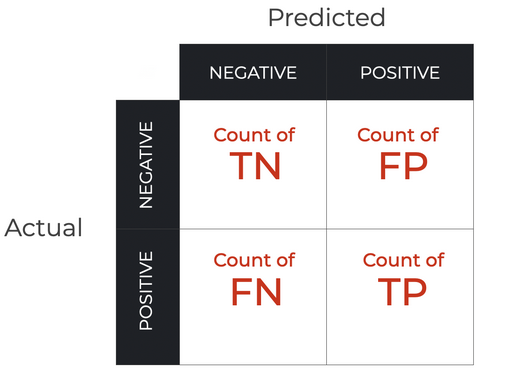

### Logistic Regression

In [520]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()

In [521]:
classifier.fit(X_train,y_train)

LogisticRegression()

In [522]:
y_pred = classifier.predict(X_test)

In [523]:

eval_metric(classifier, X_train, y_train, X_test, y_test)

Test_Set
[[5 1]
 [1 2]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.67      0.67      0.67         3

    accuracy                           0.78         9
   macro avg       0.75      0.75      0.75         9
weighted avg       0.78      0.78      0.78         9


Train_Set
[[34  4]
 [ 4 37]]
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        38
           1       0.90      0.90      0.90        41

    accuracy                           0.90        79
   macro avg       0.90      0.90      0.90        79
weighted avg       0.90      0.90      0.90        79



In [524]:
pol_feature = PolynomialFeatures(degree=2)
X_train = pol_feature.fit_transform(X_train)

In [525]:
X_train.shape

(79, 300)

In [526]:
X_test = pol_feature.transform(X_test)

In [527]:
classifier.fit(X_train,y_train)

LogisticRegression()

In [528]:
y_pred = classifier.predict(X_test)

In [529]:

eval_metric(classifier, X_train, y_train, X_test, y_test)

Test_Set
[[5 1]
 [2 1]]
              precision    recall  f1-score   support

           0       0.71      0.83      0.77         6
           1       0.50      0.33      0.40         3

    accuracy                           0.67         9
   macro avg       0.61      0.58      0.58         9
weighted avg       0.64      0.67      0.65         9


Train_Set
[[38  0]
 [ 0 41]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        41

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



### TESTING NEVER SEEN CASES

In [530]:
dft1 = pd.read_csv('CSV/test1.csv')
dft1.shape

(2, 1180)

In [531]:
dft2 = pd.read_csv('CSV/test2.csv')
dft2.shape

(3, 1180)

In [532]:
dfT =  pd.concat([dft1,dft2], axis = 0, ignore_index= 1)

In [533]:
dfT.shape

(5, 1180)

In [534]:
col_list = df_pca.columns.to_list()

In [535]:
dfU.loc[:,col_list]

,mask_voxel_count,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,...,diagnostics_Mask-original_VoxelNum,diagnostics_Mask-original_VolumeNum,diagnostics_Image-interpolated_Mean,diagnostics_Image-interpolated_Minimum,diagnostics_Image-interpolated_Maximum,diagnostics_Mask-interpolated_VoxelNum,diagnostics_Mask-interpolated_VolumeNum,diagnostics_Mask-interpolated_Mean,diagnostics_Mask-interpolated_Minimum,diagnostics_Mask-interpolated_Maximum
0,42778,0.876849,0.855422,44.989674,52.593548,60.835845,63.134776,61.554854,68.278840,72956.541667,...,42778,1,66.833184,-13.432264,104.877320,73025,1,66.291850,53.140933,93.070440
1,51331,0.878046,0.695152,40.831704,58.737773,66.400301,58.830264,65.855903,73.627441,85475.875000,...,51331,1,95.173894,30.696134,180.325897,85545,1,98.531768,78.597424,150.642359
2,129552,0.852747,0.563577,47.799028,84.813666,81.215762,71.568149,102.825094,104.737768,200990.333333,...,129552,1,79.088292,-5.717799,103.807765,201086,1,80.296722,3.160067,103.133532
3,4274,0.937813,0.897855,19.000150,21.161704,24.186773,24.698178,25.495098,27.820855,5403.291667,...,4274,1,115.262925,-104.480156,192.683603,5430,1,122.921304,9.143851,169.727193
4,10674,0.740761,0.714621,27.966907,39.135298,41.340053,41.880783,36.124784,47.307505,20987.791667,...,10674,1,79.707439,-51.116383,138.721623,21030,1,82.487785,55.784986,107.448790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,1422,0.883148,0.663019,11.334360,17.095071,16.643317,17.492856,19.209373,21.794495,1905.625000,...,1422,1,89.401980,73.746965,169.436028,1924,1,95.745366,74.295690,108.845700
84,119828,0.972461,0.808961,49.802279,61.563292,72.670489,72.249567,68.963759,73.348483,131323.250000,...,119828,1,93.316510,-23.177235,208.051762,131402,1,102.201652,80.424154,135.642127
85,79903,0.997174,0.792661,54.374557,68.597471,72.138755,69.462220,90.520716,92.309263,175836.666667,...,79903,1,88.762854,55.314839,322.361662,175932,1,97.777580,57.364347,141.232159
86,55592,0.907156,0.689452,51.911389,75.293693,76.295478,68.963759,98.595132,100.229736,184005.458333,...,55592,1,66.399308,-5.115776,127.005411,184100,1,69.653952,47.326367,93.614922


In [536]:
#### dfT.loc[:,col_list]

In [537]:
dfT_scaled = sc.transform(dfT.loc[:,col_list])

In [538]:
dfT_scaled.shape

(5, 1144)

In [539]:
scaled_df_pca.shape

(88, 1144)

In [540]:
p_dfT_scaled = pca.transform(dfT_scaled)

In [541]:
p_dfT_scaled.shape 

(5, 23)

In [542]:
svc.predict(p_dfT_scaled)

array([0, 0, 1, 1, 1])

In [547]:
dfT.pathology

0    angiomyolipoma
1    angiomyolipoma
2        clear cell
3        clear cell
4       chromophobe
Name: pathology, dtype: object

In [548]:
dfRS.pathology.value_counts()

pathology
clear cell     40
papillary       3
chromophobe     1
Name: count, dtype: int64

In [185]:
dfU.tumor_type.value_counts()

tumor_type
0.0    58
2.0    44
Name: count, dtype: int64

In [189]:
col_list[-50:-1]

['wavelet-LLL_glrlm_ShortRunHighGrayLevelEmphasis',
 'wavelet-LLL_glrlm_ShortRunLowGrayLevelEmphasis',
 'wavelet-LLL_glszm_GrayLevelNonUniformity',
 'wavelet-LLL_glszm_GrayLevelNonUniformityNormalized',
 'wavelet-LLL_glszm_GrayLevelVariance',
 'wavelet-LLL_glszm_HighGrayLevelZoneEmphasis',
 'wavelet-LLL_glszm_LargeAreaEmphasis',
 'wavelet-LLL_glszm_LargeAreaHighGrayLevelEmphasis',
 'wavelet-LLL_glszm_LargeAreaLowGrayLevelEmphasis',
 'wavelet-LLL_glszm_LowGrayLevelZoneEmphasis',
 'wavelet-LLL_glszm_SizeZoneNonUniformity',
 'wavelet-LLL_glszm_SizeZoneNonUniformityNormalized',
 'wavelet-LLL_glszm_SmallAreaEmphasis',
 'wavelet-LLL_glszm_SmallAreaHighGrayLevelEmphasis',
 'wavelet-LLL_glszm_SmallAreaLowGrayLevelEmphasis',
 'wavelet-LLL_glszm_ZoneEntropy',
 'wavelet-LLL_glszm_ZonePercentage',
 'wavelet-LLL_glszm_ZoneVariance',
 'wavelet-LLL_gldm_DependenceEntropy',
 'wavelet-LLL_gldm_DependenceNonUniformity',
 'wavelet-LLL_gldm_DependenceNonUniformityNormalized',
 'wavelet-LLL_gldm_Dependence

In [190]:
col_list[-1]

'diagnostics_Mask-interpolated_Maximum'

### LASSO 

In [55]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

def select_features_with_lasso(X: pd.DataFrame, y: pd.Series, cv_folds: int = 5) -> tuple[pd.DataFrame, list[str]]:
    """
    Applies LASSO (L1 regularization) to automatically select the most impactful features.
    
    Parameters:
    -----------
    X : pd.DataFrame
        Your radiomics feature matrix (shape: samples x 1145 features)
    y : pd.Series or np.ndarray
        Target labels (e.g., 0 for RCC, 1 for AML)
    cv_folds : int, default=5
        Number of cross-validation folds for tuning the penalty parameter (alpha)
        
    Returns:
    --------
    X_selected : pd.DataFrame
        The filtered feature matrix containing only non-zero coefficient features.
    selected_features : list
        List of strings containing the names of the chosen features.
    """
    print(f"Starting LASSO feature selection. Original feature count: {X.shape[1]}")
    
    # 1. Scale features (Crucial for LASSO; features with larger magnitudes dominate penalization)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 2. Instantiate LassoCV to find the optimal alpha (penalty strength) automatically
    # We use a high max_iter because radiomics features can have high multicollinearity
    lasso_cv = LassoCV(
        cv=cv_folds, 
        random_state=42, 
        max_iter=10000, 
        n_jobs=-1
    )
    
    # 3. Fit the model
    lasso_cv.fit(X_scaled, y)
    print(f"Optimal regularization penalty (alpha parameter): {lasso_cv.alpha_:.6f}")
    
    # 4. Extract non-zero coefficients
    lasso_coefficients = lasso_cv.coef_
    selected_mask = lasso_coefficients != 0
    selected_features = X.columns[selected_mask].tolist()
    
    print(f"LASSO completed. Retained {len(selected_features)} features / dropped {X.shape[1] - len(selected_features)} features.")
    
    # 5. Filter the original dataframe
    X_selected = X[selected_features].copy()
    
    # Optional: Print out a quick report of the selected features and their weights
    print("\nTop Selected Features & Weights:")
    features_weights = sorted(
        zip(selected_features, lasso_coefficients[selected_mask]), 
        key=lambda item: abs(item[1]), 
        reverse=True
    )
    for feat, weight in features_weights[:15]:  # Show top 15
        print(f"  {feat:<50} : Coefficient = {weight:.4f}")
        
    if len(features_weights) > 15:
        print(f"  ... and {len(features_weights) - 15} more features.")
        
    return X_selected, selected_features

# ─── HOW TO RUN IT ON YOUR DATASET ──────────────────────────────────────────
# Assuming 'df' is your final dataframe after pyradiomics extraction
# and 'tumor_type' is your target label (0 or 1)

# feature_cols = [col for col in df.columns if col != 'tumor_type']
# X = df[feature_cols]
# y = df['tumor_type']

# X_reduced, chosen_feature_names = select_features_with_lasso(X, y, cv_folds=5)

In [ ]:
select_features_with_lasso()

In [ ]:
dfU.select_dtypes(exclude = "object").shape
dfU.drop(columns=['case_id','augmentation','source_subset','target'],axis=1).select_dtypes(exclude = "object").shape
df_pca = dfU.drop(['case_id','augmentation','source_subset','target','tumor_type'],axis=1).select_dtypes(exclude = "object")
sc = StandardScaler()
df_pca.shapescaled_df_pca = sc.fit_transform(df_pca)

In [56]:
lasso_df = dfU.drop(['case_id','augmentation','source_subset','target','tumor_type'],axis=1).select_dtypes(exclude = "object")


In [57]:
select_features_with_lasso(lasso_df, y, 5)

Starting LASSO feature selection. Original feature count: 1144
Optimal regularization penalty (alpha parameter): 0.002377
LASSO completed. Retained 71 features / dropped 1073 features.

Top Selected Features & Weights:
  wavelet-LLH_glrlm_LongRunLowGrayLevelEmphasis      : Coefficient = -0.2351
  wavelet-HLL_glcm_InverseVariance                   : Coefficient = -0.1551
  wavelet-LLL_glcm_Idmn                              : Coefficient = 0.1440
  log-sigma-2-0-mm-3D_firstorder_Skewness            : Coefficient = 0.1384
  wavelet-LHL_glszm_SizeZoneNonUniformityNormalized  : Coefficient = -0.1362
  wavelet-LHL_gldm_DependenceVariance                : Coefficient = 0.1253
  wavelet-LHH_glcm_Imc2                              : Coefficient = 0.1199
  wavelet-HHH_gldm_LargeDependenceLowGrayLevelEmphasis : Coefficient = -0.1185
  original_shape_Flatness                            : Coefficient = -0.0965
  wavelet-LHL_glcm_InverseVariance                   : Coefficient = 0.0934
  wavelet-LHL_

(    original_shape_Elongation  original_shape_Flatness  \
 0                    0.876849                 0.855422   
 1                    0.878046                 0.695152   
 2                    0.852747                 0.563577   
 3                    0.937813                 0.897855   
 4                    0.740761                 0.714621   
 ..                        ...                      ...   
 83                   0.902323                 0.490950   
 84                   0.914106                 0.814599   
 85                   0.907156                 0.689452   
 86                   0.857842                 0.795976   
 87                   0.895220                 0.798958   
 
     original_shape_Sphericity  original_glcm_ClusterProminence  \
 0                    0.771342                       150.484895   
 1                    0.785540                       153.669651   
 2                    0.760093                       263.158053   
 3                    

In [58]:
columns = ['original_shape_Elongation',
  'original_shape_Flatness',
  'original_shape_Sphericity',
  'original_glcm_ClusterProminence',
  'original_glrlm_LongRunHighGrayLevelEmphasis',
  'original_glrlm_ShortRunLowGrayLevelEmphasis',
  'original_glszm_LargeAreaHighGrayLevelEmphasis',
  'log-sigma-1-0-mm-3D_firstorder_Skewness',
  'log-sigma-1-0-mm-3D_glcm_MaximumProbability',
  'log-sigma-1-0-mm-3D_glszm_SmallAreaLowGrayLevelEmphasis',
  'log-sigma-2-0-mm-3D_firstorder_Kurtosis',
  'log-sigma-2-0-mm-3D_firstorder_Skewness',
  'log-sigma-2-0-mm-3D_glszm_GrayLevelNonUniformityNormalized',
  'log-sigma-2-0-mm-3D_glszm_SmallAreaEmphasis',
  'log-sigma-2-0-mm-3D_glszm_SmallAreaLowGrayLevelEmphasis',
  'log-sigma-3-0-mm-3D_firstorder_Median',
  'log-sigma-3-0-mm-3D_glcm_ClusterProminence',
  'log-sigma-3-0-mm-3D_glcm_Imc1',
  'log-sigma-3-0-mm-3D_glszm_GrayLevelNonUniformity',
  'log-sigma-3-0-mm-3D_glszm_GrayLevelNonUniformityNormalized',
  'log-sigma-3-0-mm-3D_glszm_LowGrayLevelZoneEmphasis',
  'log-sigma-3-0-mm-3D_glszm_SizeZoneNonUniformity',
  'log-sigma-3-0-mm-3D_glszm_SmallAreaEmphasis',
  'wavelet-LLH_firstorder_Skewness',
  'wavelet-LLH_glrlm_LongRunLowGrayLevelEmphasis',
  'wavelet-LLH_glszm_SizeZoneNonUniformityNormalized',
  'wavelet-LLH_gldm_DependenceVariance',
  'wavelet-LHL_glcm_Imc2',
  'wavelet-LHL_glcm_InverseVariance',
  'wavelet-LHL_glszm_LowGrayLevelZoneEmphasis',
  'wavelet-LHL_glszm_SizeZoneNonUniformityNormalized',
  'wavelet-LHL_gldm_DependenceVariance',
  'wavelet-LHH_firstorder_Mean',
  'wavelet-LHH_firstorder_Median',
  'wavelet-LHH_firstorder_Skewness',
  'wavelet-LHH_glcm_Imc2',
  'wavelet-LHH_glrlm_LongRunHighGrayLevelEmphasis',
  'wavelet-LHH_glszm_GrayLevelNonUniformityNormalized',
  'wavelet-LHH_glszm_LargeAreaLowGrayLevelEmphasis',
  'wavelet-LHH_glszm_SmallAreaLowGrayLevelEmphasis',
  'wavelet-HLL_firstorder_Skewness',
  'wavelet-HLL_glcm_Idn',
  'wavelet-HLL_glcm_InverseVariance',
  'wavelet-HLL_glrlm_LongRunHighGrayLevelEmphasis',
  'wavelet-HLL_glrlm_RunVariance',
  'wavelet-HLL_glszm_GrayLevelNonUniformity',
  'wavelet-HLH_firstorder_Skewness',
  'wavelet-HLH_glcm_ClusterTendency',
  'wavelet-HLH_glszm_GrayLevelNonUniformityNormalized',
  'wavelet-HLH_glszm_LowGrayLevelZoneEmphasis',
  'wavelet-HLH_glszm_SizeZoneNonUniformityNormalized',
  'wavelet-HHL_firstorder_Kurtosis',
  'wavelet-HHL_firstorder_Mean',
  'wavelet-HHL_glcm_Imc2',
  'wavelet-HHL_glszm_GrayLevelNonUniformity',
  'wavelet-HHL_glszm_GrayLevelNonUniformityNormalized',
  'wavelet-HHL_glszm_GrayLevelVariance',
  'wavelet-HHL_glszm_LowGrayLevelZoneEmphasis',
  'wavelet-HHL_ngtdm_Busyness',
  'wavelet-HHL_ngtdm_Strength',
  'wavelet-HHH_glszm_GrayLevelNonUniformityNormalized',
  'wavelet-HHH_glszm_LargeAreaLowGrayLevelEmphasis',
  'wavelet-HHH_glszm_LowGrayLevelZoneEmphasis',
  'wavelet-HHH_glszm_ZoneVariance',
  'wavelet-HHH_gldm_LargeDependenceLowGrayLevelEmphasis',
  'wavelet-LLL_firstorder_Skewness',
  'wavelet-LLL_glcm_Idmn',
  'wavelet-LLL_glcm_Imc2',
  'wavelet-LLL_ngtdm_Strength',
  'diagnostics_Image-interpolated_Minimum',
  'diagnostics_Image-interpolated_Maximum']

In [59]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf')

In [60]:
X = lasso_df.loc[:, columns]

In [61]:
sc = StandardScaler()

In [62]:
X_train,X_test , y_train, y_test = train_test_split(X,y,test_size= 0.1, stratify=y)

In [64]:
X_train_sc = sc.fit_transform(X_train)

In [65]:
X_test_sc = sc.transform(X_test)

In [66]:
svc.fit(X_train_sc,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [67]:
y_pred = svc.predict(X_test_sc)

In [69]:
np.concatenate(y_pred,y_test)

TypeError: 'Series' object cannot be interpreted as an integer

In [70]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

In [72]:
eval_metric(svc, X_train_sc,y_train,X_test_sc, y_test)

Test_Set
[[4 1]
 [1 3]]
              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.75      0.75      0.75         4

    accuracy                           0.78         9
   macro avg       0.78      0.78      0.78         9
weighted avg       0.78      0.78      0.78         9


Train_Set
[[39  0]
 [ 0 40]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       1.00      1.00      1.00        40

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



In [138]:
dft1 = pd.read_csv('CSV/test1.csv')
dft1.shape


(2, 1180)

In [139]:
dft2 = pd.read_csv('CSV/test2.csv')
dft2.shape


(3, 1180)

In [140]:
dfT =  pd.concat([dft1,dft2], axis = 0, ignore_index= 1)


In [77]:
dfT.loc[:,columns]

,original_shape_Elongation,original_shape_Flatness,original_shape_Sphericity,original_glcm_ClusterProminence,original_glrlm_LongRunHighGrayLevelEmphasis,original_glrlm_ShortRunLowGrayLevelEmphasis,original_glszm_LargeAreaHighGrayLevelEmphasis,log-sigma-1-0-mm-3D_firstorder_Skewness,log-sigma-1-0-mm-3D_glcm_MaximumProbability,log-sigma-1-0-mm-3D_glszm_SmallAreaLowGrayLevelEmphasis,...,wavelet-HHH_glszm_LargeAreaLowGrayLevelEmphasis,wavelet-HHH_glszm_LowGrayLevelZoneEmphasis,wavelet-HHH_glszm_ZoneVariance,wavelet-HHH_gldm_LargeDependenceLowGrayLevelEmphasis,wavelet-LLL_firstorder_Skewness,wavelet-LLL_glcm_Idmn,wavelet-LLL_glcm_Imc2,wavelet-LLL_ngtdm_Strength,diagnostics_Image-interpolated_Minimum,diagnostics_Image-interpolated_Maximum
0,0.841058,0.807857,0.775735,13.380345,415.696148,0.030542,8.755422e+06,0.666294,0.379613,0.108985,...,4.531486e+06,0.625,441.00,101.186987,-1.035922,0.995136,0.900335,0.336247,77.656555,127.097652
1,0.790875,0.631394,0.779468,702.210809,212.046970,0.023120,7.765630e+05,-0.378374,0.280976,0.037951,...,9.660025e+05,0.625,90.25,96.574141,-0.516973,0.994310,0.934162,4.547313,-122.930227,147.131874
2,0.943968,0.606594,0.737446,1189.912602,335.018538,0.052754,3.452516e+07,-0.472643,0.417305,0.088314,...,2.275721e+08,0.625,484.00,112.718820,0.186110,0.996474,0.987921,0.424491,-32.790072,139.409458
3,0.418093,0.387676,0.704647,540.874884,294.476095,0.032126,6.681924e+06,0.646855,0.463767,0.103354,...,5.496812e+06,0.625,182.25,106.634911,-0.833991,0.991357,0.961879,1.066915,68.787269,143.270837
4,0.971305,0.703365,0.735525,16.705348,260.737295,0.033347,1.385409e+07,0.490286,0.389625,0.117097,...,2.271957e+07,0.625,90.25,101.611397,-0.933165,0.993789,0.908960,0.131891,54.969240,88.770727


In [79]:
dfT_scaled = sc.transform(dfT.loc[:,columns])
dfT_scaled.shape

(5, 71)

In [81]:
svc.predict(dfT_scaled)

array([0, 0, 0, 0, 1])

In [82]:
columns

['original_shape_Elongation',
 'original_shape_Flatness',
 'original_shape_Sphericity',
 'original_glcm_ClusterProminence',
 'original_glrlm_LongRunHighGrayLevelEmphasis',
 'original_glrlm_ShortRunLowGrayLevelEmphasis',
 'original_glszm_LargeAreaHighGrayLevelEmphasis',
 'log-sigma-1-0-mm-3D_firstorder_Skewness',
 'log-sigma-1-0-mm-3D_glcm_MaximumProbability',
 'log-sigma-1-0-mm-3D_glszm_SmallAreaLowGrayLevelEmphasis',
 'log-sigma-2-0-mm-3D_firstorder_Kurtosis',
 'log-sigma-2-0-mm-3D_firstorder_Skewness',
 'log-sigma-2-0-mm-3D_glszm_GrayLevelNonUniformityNormalized',
 'log-sigma-2-0-mm-3D_glszm_SmallAreaEmphasis',
 'log-sigma-2-0-mm-3D_glszm_SmallAreaLowGrayLevelEmphasis',
 'log-sigma-3-0-mm-3D_firstorder_Median',
 'log-sigma-3-0-mm-3D_glcm_ClusterProminence',
 'log-sigma-3-0-mm-3D_glcm_Imc1',
 'log-sigma-3-0-mm-3D_glszm_GrayLevelNonUniformity',
 'log-sigma-3-0-mm-3D_glszm_GrayLevelNonUniformityNormalized',
 'log-sigma-3-0-mm-3D_glszm_LowGrayLevelZoneEmphasis',
 'log-sigma-3-0-mm-3D_gls

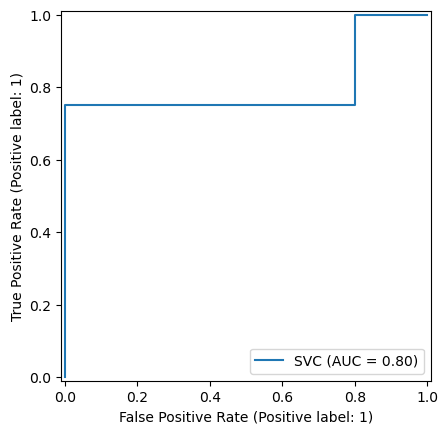

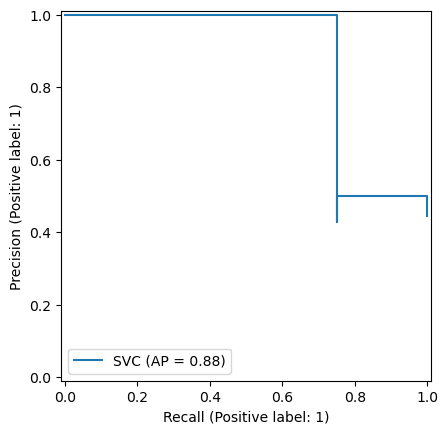

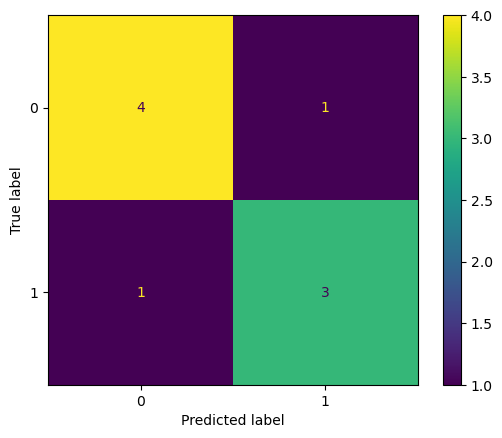

In [84]:
from sklearn.metrics import RocCurveDisplay,PrecisionRecallDisplay,ConfusionMatrixDisplay
RocCurveDisplay.from_estimator(svc,X_test_sc,y_test)
plt.show()
PrecisionRecallDisplay.from_estimator(svc,X_test_sc,y_test)
plt.show()
ConfusionMatrixDisplay.from_estimator(svc,X_test_sc,y_test)
plt.show()

In [ ]:
select_features_with_lasso(lasso_df, y, 5)

In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

def run_nested_cv(X: pd.DataFrame, y: pd.Series):
    """
    Executes a Nested Cross-Validation loop.
    Inner Loop: Feature Scaling -> LASSO Selection -> Hyperparameter Tuning
    Outer Loop: Unbiased Performance Evaluation
    """
    # ─── 1. DEFINE THE INNER PIPELINE ────────────────────────────────────────
    # Standardize -> Select features via LASSO -> Classify
    # We use SelectFromModel with LassoCV to automate the inner feature selection
    lasso_selector = SelectFromModel(
        LassoCV(cv=3, max_iter=10000, random_state=42, n_jobs=-1)
    )
    
    # You can change this classifier to XGBoost, SVM, or Random Forest
    classifier = RandomForestClassifier(random_state=42)
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', lasso_selector),
        ('classifier', classifier)
    ])
    
    # ─── 2. HYPERPARAMETER TUNING GRID (INNER LOOP) ──────────────────────────
    # Define what the inner loop should search through.
    param_grid = {
        # Try different tree counts for Random Forest
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [None, 5, 10],
        # You can also adjust the LASSO threshold if needed
        'selector__threshold': ['mean', 'median'] 
    }

    # ─── 3. SETUP CROSS-VALIDATION SPLITS ────────────────────────────────────
    # StratifiedKFold maintains class balance (RCC vs AML ratio) across folds
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Storage arrays for outer loop evaluation metrics
    outer_auc_scores = []
    outer_accuracy_scores = []
    
    print("🔄 Starting Nested Cross-Validation Loop...")
    print(f"Outer Loops: {outer_cv.get_n_splits()} folds | Inner Loops: {inner_cv.get_n_splits()} folds\n")

    # ─── 4. OUTER LOOP ───────────────────────────────────────────────────────
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # GridSearch acts as our automated Inner Loop
        inner_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=0
        )
        
        # Fit the inner loop (Scales, runs LASSO, tunes RF parameters per fold)
        inner_search.fit(X_train, y_train)
        
        # Get best estimator from this fold's inner search
        best_model = inner_search.best_estimator_
        
        # Track how many features LASSO actually passed to the classifier in this fold
        features_retained = best_model.named_steps['selector'].get_support()
        num_features = np.sum(features_retained)
        
        # Predict on the strictly isolated outer test set
        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)[:, 1]
        
        # Evaluate performance
        fold_auc = roc_auc_score(y_test, y_proba)
        fold_acc = accuracy_score(y_test, y_pred)
        
        outer_auc_scores.append(fold_auc)
        outer_accuracy_scores.append(fold_acc)
        
        print(f"🔹 Outer Fold {fold}:")
        print(f"   Selected Features : {num_features} / {X.shape[1]}")
        print(f"   Best Parameters   : {inner_search.best_params_}")
        print(f"   Test AUC          : {fold_auc:.4f} | Test Accuracy: {fold_acc:.4f}\n")

    # ─── 5. FINAL REPORTING ──────────────────────────────────────────────────
    print("═══ FINAL NESTED CV RESULTS ═══")
    print(f"Mean Test AUC     : {np.mean(outer_auc_scores):.4f} ± {np.std(outer_auc_scores):.4f}")
    print(f"Mean Test Accuracy: {np.mean(outer_accuracy_scores):.4f} ± {np.std(outer_accuracy_scores):.4f}")
    print("===============================")

# ─── HOW TO EXECUTE ──────────────────────────────────────────────────────────
# feature_cols = [col for col in df.columns if col != 'tumor_type']
# X = df[feature_cols]
# y = df['tumor_type']
# run_nested_cv(X, y)

In [44]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

def run_nested_cv(X: pd.DataFrame, y: pd.Series) -> dict:
    """
    Executes a Nested Cross-Validation loop.
    Inner Loop: Feature Scaling -> LASSO Selection -> Hyperparameter Tuning
    Outer Loop: Unbiased Performance Evaluation
    
    Returns:
    --------
    fold_artifacts : dict
        A dictionary containing the scaler, LASSO-selected feature list, 
        and trained model object for each outer fold.
    """
    # ─── 1. DEFINE THE INNER PIPELINE ────────────────────────────────────────
    lasso_selector = SelectFromModel(
        LassoCV(cv=3, max_iter=10000, random_state=42, n_jobs=-1)
    )
    
    classifier = RandomForestClassifier(random_state=42)
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', lasso_selector),
        ('classifier', classifier)
    ])
    
    # ─── 2. HYPERPARAMETER TUNING GRID (INNER LOOP) ──────────────────────────
    param_grid = {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [None, 5, 10],
        'selector__threshold': ['mean', 'median'] 
    }

    # ─── 3. SETUP CROSS-VALIDATION SPLITS ────────────────────────────────────
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Storage arrays for outer loop evaluation metrics
    outer_auc_scores = []
    outer_accuracy_scores = []
    
    # 🚨 TRACKING DICTIONARY FOR ARTIFACT EXTRACTION
    fold_artifacts = {}
    
    print("🔄 Starting Nested Cross-Validation Loop...")
    print(f"Outer Loops: {outer_cv.get_n_splits()} folds | Inner Loops: {inner_cv.get_n_splits()} folds\n")

    # ─── 4. OUTER LOOP ───────────────────────────────────────────────────────
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # GridSearch acts as our automated Inner Loop
        inner_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=0
        )
        
        # Fit the inner loop (Scales, runs LASSO, tunes RF parameters per fold)
        inner_search.fit(X_train, y_train)
        
        # Get best estimator from this fold's inner search
        best_model = inner_search.best_estimator_
        
        # 🚨 EXTRACTION LOGIC
        feature_mask = best_model.named_steps['selector'].get_support()
        selected_features = X.columns[feature_mask].tolist()
        num_features = len(selected_features)
        
        # Store objects in the artifacts dictionary
        fold_artifacts[f"Fold_{fold}"] = {
            "model_name": best_model.named_steps['classifier'].__class__.__name__,
            "model_object": best_model.named_steps['classifier'],
            "selected_features": selected_features,
            "scaler_object": best_model.named_steps['scaler'],
            "best_params": inner_search.best_params_
        }
        
        # Predict on the strictly isolated outer test set
        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)[:, 1]
        
        # Evaluate performance
        fold_auc = roc_auc_score(y_test, y_proba)
        fold_acc = accuracy_score(y_test, y_pred)
        
        outer_auc_scores.append(fold_auc)
        outer_accuracy_scores.append(fold_acc)
        
        print(f"🔹 Outer Fold {fold}:")
        print(f"   Selected Features : {num_features} / {X.shape[1]}")
        print(f"   Best Parameters   : {inner_search.best_params_}")
        print(f"   Test AUC          : {fold_auc:.4f} | Test Accuracy: {fold_acc:.4f}\n")

    # ─── 5. FINAL REPORTING ──────────────────────────────────────────────────
    print("═══ FINAL NESTED CV RESULTS ═══")
    print(f"Mean Test AUC     : {np.mean(outer_auc_scores):.4f} ± {np.std(outer_auc_scores):.4f}")
    print(f"Mean Test Accuracy: {np.mean(outer_accuracy_scores):.4f} ± {np.std(outer_accuracy_scores):.4f}")
    print("===============================")

    # 🚨 CRITICAL FIX: Explicitly return the saved artifacts back to memory
    return fold_artifacts

In [32]:
fold_artifacts

NameError: name 'fold_artifacts' is not defined

In [28]:
run_nested_cv(X, y)

🔄 Starting Nested Cross-Validation Loop...
Outer Loops: 5 folds | Inner Loops: 3 folds

🔹 Outer Fold 1:
   Selected Features : 1 / 1145
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'selector__threshold': 'mean'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 2:
   Selected Features : 1 / 1145
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'selector__threshold': 'mean'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 3:
   Selected Features : 1 / 1145
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'selector__threshold': 'mean'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 4:
   Selected Features : 1 / 1145
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'selector__threshold': 'mean'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 5:
   Selected 

In [31]:
# 1. Run the updated function and store artifacts securely



# 2. Extract components from Fold 5 (The 73-feature model)
chosen_fold = "Fold_5"
feature_list = fold_artifacts[chosen_fold]['selected_features']
scaler_obj   = fold_artifacts[chosen_fold]['scaler_object']
model_obj    = fold_artifacts[chosen_fold]['model_object']

# 3. Apply features and scaler on the unseen dataset
X_unseen_raw    = df_new.loc[:, feature_list] # Slices out matching 73 features in correct order
X_unseen_scaled = scaler_obj.transform(X_unseen_raw) # Preprocesses with training baselines

# 4. Generate classifications
predictions   = model_obj.predict(X_unseen_scaled)
probabilities = model_obj.predict_proba(X_unseen_scaled)[:, 1]

print("\n🚀 Unseen data successfully processed through Fold 5 components!")

NameError: name 'fold_artifacts' is not defined

In [ ]:
feature_list = fold_artifacts[chosen_fold]['selected_features']

In [91]:
run_nested_cv(df.loc[:,columns], df['target'])

🔄 Starting Nested Cross-Validation Loop...
Outer Loops: 5 folds | Inner Loops: 3 folds

🔹 Outer Fold 1:
   Selected Features : 36 / 71
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 2:
   Selected Features : 36 / 71
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 0.9259 | Test Accuracy: 0.9048

🔹 Outer Fold 3:
   Selected Features : 36 / 71
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 0.9697 | Test Accuracy: 0.9000

🔹 Outer Fold 4:
   Selected Features : 36 / 71
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 100, 'selector__threshold': 'median'}
   Test AUC          : 0.7475 | Test Accuracy: 0.8500

🔹 Outer Fold 5:
   S

In [98]:
run_nested_cv(df.drop(['pathology_grade','augmentation','source_subset','target','tumor_type'],axis=1).select_dtypes(exclude = "object"), df['target'])


🔄 Starting Nested Cross-Validation Loop...
Outer Loops: 5 folds | Inner Loops: 3 folds

🔹 Outer Fold 1:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 0.9722 | Test Accuracy: 0.8571

🔹 Outer Fold 2:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'selector__threshold': 'median'}
   Test AUC          : 0.9120 | Test Accuracy: 0.8095

🔹 Outer Fold 3:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 4:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'selector__threshold': 'median'}
   Test AUC          : 0.8990 | Test Accuracy: 0.8000

🔹 Outer Fol

C:\Users\HP-Gayrettepe\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.583e-03, tolerance: 2.020e-03
  model = cd_fast.enet_coordinate_descent(


In [100]:
artifacts = run_nested_cv(df.drop(['pathology_grade','augmentation','source_subset','target','tumor_type'],axis=1).select_dtypes(exclude = "object"), df['target'])


🔄 Starting Nested Cross-Validation Loop...
Outer Loops: 5 folds | Inner Loops: 3 folds

🔹 Outer Fold 1:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 0.9722 | Test Accuracy: 0.8571

🔹 Outer Fold 2:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'selector__threshold': 'median'}
   Test AUC          : 0.9120 | Test Accuracy: 0.8095

🔹 Outer Fold 3:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 4:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'selector__threshold': 'median'}
   Test AUC          : 0.8990 | Test Accuracy: 0.8000

🔹 Outer Fol

C:\Users\HP-Gayrettepe\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.583e-03, tolerance: 2.020e-03
  model = cd_fast.enet_coordinate_descent(


In [105]:
# 1. Run the updated function and store artifacts securely


artifacts = run_nested_cv(df.drop(['pathology_grade','augmentation','source_subset','target','tumor_type'],axis=1).select_dtypes(exclude = "object"), df['target'])

# 2. Extract components from Fold 5 (The 73-feature model)
chosen_fold = "Fold_5"
feature_list = artifacts[chosen_fold]['selected_features']
scaler_obj   = artifacts[chosen_fold]['scaler_object']
model_obj    = artifacts[chosen_fold]['model_object']

# 3. Apply features and scaler on the unseen dataset
X_unseen_raw    = df_new.loc[:, feature_list] # Slices out matching 73 features in correct order
X_unseen_scaled = scaler_obj.transform(X_unseen_raw) # Preprocesses with training baselines

# 4. Generate classifications
predictions   = model_obj.predict(X_unseen_scaled)
probabilities = model_obj.predict_proba(X_unseen_scaled)[:, 1]

print("\n🚀 Unseen data successfully processed through Fold 5 components!")

🔄 Starting Nested Cross-Validation Loop...
Outer Loops: 5 folds | Inner Loops: 3 folds

🔹 Outer Fold 1:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 0.9722 | Test Accuracy: 0.8571

🔹 Outer Fold 2:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'selector__threshold': 'median'}
   Test AUC          : 0.9120 | Test Accuracy: 0.8095

🔹 Outer Fold 3:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 4:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'selector__threshold': 'median'}
   Test AUC          : 0.8990 | Test Accuracy: 0.8000



C:\Users\HP-Gayrettepe\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.583e-03, tolerance: 2.020e-03
  model = cd_fast.enet_coordinate_descent(


🔹 Outer Fold 5:
   Selected Features : 73 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 50, 'selector__threshold': 'mean'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

═══ FINAL NESTED CV RESULTS ═══
Mean Test AUC     : 0.9566 ± 0.0432
Mean Test Accuracy: 0.8933 ± 0.0892


NameError: name 'df_new' is not defined

In [ ]:
# ─── STEP 1: PICK YOUR FOLD ARTIFACTS ────────────────────────────────────────
# Let's say Fold 1 gave you the best Test AUC, so you want to use its exact setup.
chosen_fold = "Fold_5"

# Extract the components we need
feature_list = artifacts[chosen_fold]['selected_features']
scaler_obj   = artifacts[chosen_fold]['scaler_object']
model_obj    = artifacts[chosen_fold]['model_object']

print(f"Loaded pipeline components from {chosen_fold}.")
print(f"Expecting exactly {len(feature_list)} features.")


# ─── STEP 2: PREPARE AND FILTER THE UNSEEN DATAFRAME ────────────────────────
# Use .loc to slice the unseen dataframe to contain ONLY the selected radiomics features.
# CRITICAL: This ensures columns are in the exact mathematical order the model expects!
X_unseen_raw = df_new.loc[:, feature_list]


# ─── STEP 3: PREPROCESS THE UNSEEN DATA ──────────────────────────────────────
# You MUST use .transform(), NOT .fit_transform(). 
# This applies the exact training means/standard deviations to the new dataset.
X_unseen_scaled = scaler_obj.transform(X_unseen_raw)


# ─── STEP 4: GENERATE PREDICTIONS ───────────────────────────────────────────
# Now it is completely safe to inject the scaled data into your trained model object.
predictions = model_obj.predict(X_unseen_scaled)
probabilities = model_obj.predict_proba(X_unseen_scaled)[:, 1]

# Save the outputs into a clean DataFrame
df_new_results = pd.DataFrame({
    'Predicted_Class': predictions,
    'Probability_of_AML': probabilities
}, index=df_new.index)

print("\n predictions completed successfully!")
print(df_new_results.head())

In [ ]:
dfT

In [127]:
# ─── STEP 1: PICK YOUR FOLD ARTIFACTS ────────────────────────────────────────
# Let's say Fold 1 gave you the best Test AUC, so you want to use its exact setup.
chosen_fold = "Fold_5"

# Extract the components we need
feature_list = artifacts[chosen_fold]['selected_features']
scaler_obj   = artifacts[chosen_fold]['scaler_object']
model_obj    = artifacts[chosen_fold]['model_object']



In [129]:
model_obj.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 50,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [130]:
feature_list

['original_shape_Elongation',
 'original_shape_Flatness',
 'original_shape_Sphericity',
 'original_glcm_Idmn',
 'original_glszm_LargeAreaHighGrayLevelEmphasis',
 'original_glszm_LowGrayLevelZoneEmphasis',
 'original_gldm_DependenceVariance',
 'log-sigma-1-0-mm-3D_firstorder_Skewness',
 'log-sigma-1-0-mm-3D_glszm_LowGrayLevelZoneEmphasis',
 'log-sigma-1-0-mm-3D_glszm_SizeZoneNonUniformityNormalized',
 'log-sigma-1-0-mm-3D_gldm_DependenceVariance',
 'log-sigma-1-0-mm-3D_ngtdm_Strength',
 'log-sigma-2-0-mm-3D_firstorder_Skewness',
 'log-sigma-2-0-mm-3D_glszm_GrayLevelNonUniformityNormalized',
 'log-sigma-2-0-mm-3D_glszm_SmallAreaEmphasis',
 'log-sigma-2-0-mm-3D_glszm_SmallAreaLowGrayLevelEmphasis',
 'log-sigma-3-0-mm-3D_firstorder_Kurtosis',
 'log-sigma-3-0-mm-3D_glrlm_ShortRunLowGrayLevelEmphasis',
 'log-sigma-3-0-mm-3D_glszm_SmallAreaEmphasis',
 'wavelet-LLH_glrlm_LongRunLowGrayLevelEmphasis',
 'wavelet-LLH_glrlm_RunVariance',
 'wavelet-LLH_glszm_SizeZoneNonUniformityNormalized',
 'wave

In [118]:
feature_list

['original_shape_Elongation',
 'original_shape_Flatness',
 'original_shape_Sphericity',
 'original_glcm_Idmn',
 'original_glszm_LargeAreaHighGrayLevelEmphasis',
 'original_glszm_LowGrayLevelZoneEmphasis',
 'original_gldm_DependenceVariance',
 'log-sigma-1-0-mm-3D_firstorder_Skewness',
 'log-sigma-1-0-mm-3D_glszm_LowGrayLevelZoneEmphasis',
 'log-sigma-1-0-mm-3D_glszm_SizeZoneNonUniformityNormalized',
 'log-sigma-1-0-mm-3D_gldm_DependenceVariance',
 'log-sigma-1-0-mm-3D_ngtdm_Strength',
 'log-sigma-2-0-mm-3D_firstorder_Skewness',
 'log-sigma-2-0-mm-3D_glszm_GrayLevelNonUniformityNormalized',
 'log-sigma-2-0-mm-3D_glszm_SmallAreaEmphasis',
 'log-sigma-2-0-mm-3D_glszm_SmallAreaLowGrayLevelEmphasis',
 'log-sigma-3-0-mm-3D_firstorder_Kurtosis',
 'log-sigma-3-0-mm-3D_glrlm_ShortRunLowGrayLevelEmphasis',
 'log-sigma-3-0-mm-3D_glszm_SmallAreaEmphasis',
 'wavelet-LLH_glrlm_LongRunLowGrayLevelEmphasis',
 'wavelet-LLH_glrlm_RunVariance',
 'wavelet-LLH_glszm_SizeZoneNonUniformityNormalized',
 'wave

In [131]:
len(feature_list)

73

In [132]:
scaler_obj.feature_names_in_

array(['mask_voxel_count', 'original_shape_Elongation',
       'original_shape_Flatness', ...,
       'diagnostics_Mask-interpolated_Mean',
       'diagnostics_Mask-interpolated_Minimum',
       'diagnostics_Mask-interpolated_Maximum'],
      shape=(1144,), dtype=object)

In [134]:
scaler_obj.get_feature_names_out()

array(['mask_voxel_count', 'original_shape_Elongation',
       'original_shape_Flatness', ...,
       'diagnostics_Mask-interpolated_Mean',
       'diagnostics_Mask-interpolated_Minimum',
       'diagnostics_Mask-interpolated_Maximum'],
      shape=(1144,), dtype=object)

In [119]:
dfT.loc[:,feature_list]

,original_shape_Elongation,original_shape_Flatness,original_shape_Sphericity,original_glcm_Idmn,original_glszm_LargeAreaHighGrayLevelEmphasis,original_glszm_LowGrayLevelZoneEmphasis,original_gldm_DependenceVariance,log-sigma-1-0-mm-3D_firstorder_Skewness,log-sigma-1-0-mm-3D_glszm_LowGrayLevelZoneEmphasis,log-sigma-1-0-mm-3D_glszm_SizeZoneNonUniformityNormalized,...,wavelet-HHH_glszm_SizeZoneNonUniformity,wavelet-HHH_glszm_SizeZoneNonUniformityNormalized,wavelet-HHH_ngtdm_Contrast,wavelet-LLL_firstorder_Skewness,wavelet-LLL_glcm_Idmn,wavelet-LLL_glcm_Imc1,wavelet-LLL_glszm_GrayLevelNonUniformity,wavelet-LLL_ngtdm_Strength,diagnostics_Image-interpolated_Minimum,diagnostics_Image-interpolated_Maximum
0,0.841058,0.807857,0.775735,0.994206,8.755422e+06,0.095518,48.243055,0.666294,0.245833,0.140000,...,1.0,0.5,0.127150,-1.035922,0.995136,-0.325736,7.150000,0.336247,77.656555,127.097652
1,0.790875,0.631394,0.779468,0.993151,7.765630e+05,0.066061,22.494039,-0.378374,0.074690,0.121094,...,1.0,0.5,0.125185,-0.516973,0.994310,-0.252262,13.702550,4.547313,-122.930227,147.131874
2,0.943968,0.606594,0.737446,0.995760,3.452516e+07,0.306826,46.272209,-0.472643,0.587910,0.076446,...,1.0,0.5,0.125087,0.186110,0.996474,-0.454982,57.829178,0.424491,-32.790072,139.409458
3,0.418093,0.387676,0.704647,0.990084,6.681924e+06,0.124909,34.915426,0.646855,0.322090,0.129252,...,1.0,0.5,0.122042,-0.833991,0.991357,-0.362309,26.557789,1.066915,68.787269,143.270837
4,0.971305,0.703365,0.735525,0.991534,1.385409e+07,0.098400,40.960985,0.490286,0.225694,0.177778,...,1.0,0.5,0.128363,-0.933165,0.993789,-0.322256,16.581921,0.131891,54.969240,88.770727


In [121]:
scaler_obj.feature_names_in_

array(['mask_voxel_count', 'original_shape_Elongation',
       'original_shape_Flatness', ...,
       'diagnostics_Mask-interpolated_Mean',
       'diagnostics_Mask-interpolated_Minimum',
       'diagnostics_Mask-interpolated_Maximum'],
      shape=(1144,), dtype=object)

In [124]:
model_obj.params

AttributeError: 'RandomForestClassifier' object has no attribute 'params'

In [126]:
# 1. Run the updated function and store artifacts securely

X = df.drop(['pathology_grade','augmentation','source_subset','target','tumor_type'],axis=1).select_dtypes(exclude = "object")
y = df['target']

artifacts = run_nested_cv(X, y )

# 2. Extract components from Fold 5 (The 73-feature model)
chosen_fold = "Fold_5"
feature_list = artifacts[chosen_fold]['selected_features']
scaler_obj   = artifacts[chosen_fold]['scaler_object']
model_obj    = artifacts[chosen_fold]['model_object']

# 3. Apply features and scaler on the unseen dataset
X_unseen_raw    = dfT.loc[:, feature_list] # Slices out matching 73 features in correct order
X_unseen_scaled = scaler_obj.transform(X_unseen_raw) # Preprocesses with training baselines

# 4. Generate classifications
predictions   = model_obj.predict(X_unseen_scaled)
probabilities = model_obj.predict_proba(X_unseen_scaled)[:, 1]

print("\n🚀 Unseen data successfully processed through Fold 5 components!")

🔄 Starting Nested Cross-Validation Loop...
Outer Loops: 5 folds | Inner Loops: 3 folds

🔹 Outer Fold 1:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 0.9722 | Test Accuracy: 0.8571

🔹 Outer Fold 2:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'selector__threshold': 'median'}
   Test AUC          : 0.9120 | Test Accuracy: 0.8095

🔹 Outer Fold 3:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': None, 'classifier__n_estimators': 200, 'selector__threshold': 'median'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

🔹 Outer Fold 4:
   Selected Features : 1144 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'selector__threshold': 'median'}
   Test AUC          : 0.8990 | Test Accuracy: 0.8000



C:\Users\HP-Gayrettepe\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.583e-03, tolerance: 2.020e-03
  model = cd_fast.enet_coordinate_descent(


🔹 Outer Fold 5:
   Selected Features : 73 / 1144
   Best Parameters   : {'classifier__max_depth': 5, 'classifier__n_estimators': 50, 'selector__threshold': 'mean'}
   Test AUC          : 1.0000 | Test Accuracy: 1.0000

═══ FINAL NESTED CV RESULTS ═══
Mean Test AUC     : 0.9566 ± 0.0432
Mean Test Accuracy: 0.8933 ± 0.0892


ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- diagnostics_Image-interpolated_Mean
- diagnostics_Image-original_Maximum
- diagnostics_Image-original_Mean
- diagnostics_Image-original_Minimum
- diagnostics_Mask-interpolated_Maximum
- ...


In [146]:
model_obj.predict(scaler_obj.transform(dfT.drop(['pathology_grade','tumor_type'],axis=1).select_dtypes(exclude = "object"))[:,dfT.drop(['pathology_grade','tumor_type'],axis=1).select_dtypes(exclude = "object").columns.get_indexer(feature_list)])

array([0, 0, 0, 0, 0])

In [137]:
dfT.drop(['pathology_grade','augmentation','source_subset','target','tumor_type'],axis=1).select_dtypes(exclude = "object")

KeyError: "['augmentation', 'source_subset', 'target'] not found in axis"

In [45]:
dfA= pd.concat([do,dr], axis = 0, ignore_index= 1)

In [46]:
dfA['target'] = 1

In [47]:
dfA.shape

(11, 1183)

In [48]:
dfR = pd.concat([drcc1,drcc2], axis = 0, ignore_index= 1)

In [49]:
dfR.shape

(58, 1182)

In [50]:
dfR['target'] = 0

In [51]:
dfR.shape

(58, 1183)

In [57]:
dfrcc = dfR.sample(58)

In [58]:
dfU = pd.concat([dfA,dfrcc], axis = 0, ignore_index= 1)

In [59]:
dfU.drop('pathology_grade', axis =1, inplace= True)

In [60]:
y = dfU['target']

In [61]:
X = dfU.drop(columns=['augmentation','source_subset','target'],axis=1).select_dtypes(exclude = "object")

In [62]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, make_scorer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 200 samples, 10% minority)
X, y = make_classification(
    n_samples=100, 
    n_features=10, 
    n_informative=8, 
    n_classes=2,
    weights=[0.9, 0.1], 
    flip_y=0, 
    random_state=42
)

# 2. Define the Pipeline (SMOTE -> Classifier)
# Crucial: Use imblearn's Pipeline, which automatically skips oversampling 
# on the validation/test folds during predict() or predict_proba()
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# 3. Define Hyperparameter Space for the Inner Loop
# Note the prefix 'classifier_' and 'smote_' to target specific pipeline steps
param_grid = {
    'smote__k_neighbors': [3, 5],
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [4, 6, None]
}

# 4. Set up Inner and Outer Stratified K-Fold loops
# Inner CV is the "Tuning Sandbox" to find optimal parameters
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# Outer CV measures how well the tuned model generalizes
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define metric (Average Precision / PR-AUC is best for high imbalance)
pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup (Hyperparameter Tuning)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1
)

# 6. The Outer Loop Execution (Model Evaluation)
outer_scores = []

print("--- Starting Nested Cross-Validation ---")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Isolate the Outer Test Fold from the Outer Training Dataset
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Run the inner loop tuning on the outer training fold data only
    grid_search.fit(X_train, y_train)
    
    # Extract the best model from this fold's tuning configuration
    best_model = grid_search.best_estimator_
    
    # Predict probabilities on the untouched, un-SMOTEd outer test fold
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Evaluate performance on the real, imbalanced test fold
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)
    
    print(f"Outer Fold {fold + 1} - Best Params: {grid_search.best_params_} | PR-AUC: {fold_score:.4f}")

# 7. Aggregate and Final Verification
mean_pr_auc = np.mean(outer_scores)
std_pr_auc = np.std(outer_scores)
print("\n--- Final Performance Deliverable ---")
print(f"Nested CV Mean PR-AUC: {mean_pr_auc:.4f} +/- {std_pr_auc:.4f}")

--- Starting Nested Cross-Validation ---


/home/euphrates/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
12 fits failed out of a total of 36.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/home/euphrates/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/euphrates/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/euphrates/anaconda3/lib/python3.12/site-packages/imblearn/pipeline.py

Outer Fold 1 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 100, 'smote__k_neighbors': 3} | PR-AUC: 0.2111


/home/euphrates/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
12 fits failed out of a total of 36.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/home/euphrates/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/euphrates/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/euphrates/anaconda3/lib/python3.12/site-packages/imblearn/pipeline.py

Outer Fold 2 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 100, 'smote__k_neighbors': 3} | PR-AUC: 0.7000


/home/euphrates/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
12 fits failed out of a total of 36.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/home/euphrates/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/euphrates/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/euphrates/anaconda3/lib/python3.12/site-packages/imblearn/pipeline.py

Outer Fold 3 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 100, 'smote__k_neighbors': 3} | PR-AUC: 0.8333


/home/euphrates/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
12 fits failed out of a total of 36.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/home/euphrates/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/euphrates/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/euphrates/anaconda3/lib/python3.12/site-packages/imblearn/pipeline.py

Outer Fold 4 - Best Params: {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'smote__k_neighbors': 3} | PR-AUC: 1.0000


/home/euphrates/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
12 fits failed out of a total of 36.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/home/euphrates/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/euphrates/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/euphrates/anaconda3/lib/python3.12/site-packages/imblearn/pipeline.py

Outer Fold 5 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 100, 'smote__k_neighbors': 3} | PR-AUC: 0.5000

--- Final Performance Deliverable ---
Nested CV Mean PR-AUC: 0.6489 +/- 0.2734


In [65]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
# Added confusion_matrix and accuracy_score to the imports
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 200 samples, 10% minority)
X, y = make_classification(
    n_samples=168, 
    n_features=20, 
    n_informative=8, 
    n_classes=2,
    weights=[58/69, 11/69], 
    flip_y=0, 
    random_state=42
)

# 2. Define the Pipeline (SMOTE -> Classifier)
# Crucial: Use imblearn's Pipeline, which automatically skips oversampling 
# on the validation/test folds during predict() or predict_proba()
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# 3. Define Hyperparameter Space for the Inner Loop
# Note the prefix 'classifier_' and 'smote_' to target specific pipeline steps
param_grid = {
    'smote__k_neighbors': [3, 5],
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [4, 6, None]
}

# 4. Set up Inner and Outer Stratified K-Fold loops
# Inner CV is the "Tuning Sandbox" to find optimal parameters
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# Outer CV measures how well the tuned model generalizes
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define metric (Average Precision / PR-AUC is best for high imbalance)
pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup (Hyperparameter Tuning)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1
)

# 6. The Outer Loop Execution (Model Evaluation)
outer_scores = []
outer_accuracy_scores = [] # Track accuracy per fold

print("--- Starting Nested Cross-Validation ---")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Isolate the Outer Test Fold from the Outer Training Dataset
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Run the inner loop tuning on the outer training fold data only
    grid_search.fit(X_train, y_train)
    
    # Extract the best model from this fold's tuning configuration
    best_model = grid_search.best_estimator_
    
    # Predict probabilities on the untouched, un-SMOTEd outer test fold
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test) # Added for accuracy and confusion matrix
    
    # Evaluate performance on the real, imbalanced test fold
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)
    
    fold_accuracy = accuracy_score(y_test, y_pred) # Calculate accuracy
    outer_accuracy_scores.append(fold_accuracy)
    
    fold_cm = confusion_matrix(y_test, y_pred) # Calculate confusion matrix
    
    print(f"Outer Fold {fold + 1} - Best Params: {grid_search.best_params_} | PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}")

# 7. Aggregate and Final Verification
mean_pr_auc = np.mean(outer_scores)
std_pr_auc = np.std(outer_scores)

mean_accuracy = np.mean(outer_accuracy_scores) # Aggregate accuracy mean
std_accuracy = np.std(outer_accuracy_scores)   # Aggregate accuracy standard deviation

print("\n--- Final Performance Deliverable ---")
print(f"Nested CV Mean PR-AUC: {mean_pr_auc:.4f} +/- {std_pr_auc:.4f}")
print(f"Nested CV Mean Accuracy: {mean_accuracy:.4f} +/- {std_accuracy:.4f}") # Display accuracy

--- Starting Nested Cross-Validation ---
Outer Fold 1 - Best Params: {'classifier__max_depth': None, 'classifier__n_estimators': 100, 'smote__k_neighbors': 5} | PR-AUC: 0.3752 | Accuracy: 0.8529
Confusion Matrix:
[[28  1]
 [ 4  1]]
Outer Fold 2 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 50, 'smote__k_neighbors': 5} | PR-AUC: 0.4713 | Accuracy: 0.7647
Confusion Matrix:
[[24  4]
 [ 4  2]]
Outer Fold 3 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 50, 'smote__k_neighbors': 3} | PR-AUC: 0.3425 | Accuracy: 0.7059
Confusion Matrix:
[[24  4]
 [ 6  0]]
Outer Fold 4 - Best Params: {'classifier__max_depth': None, 'classifier__n_estimators': 100, 'smote__k_neighbors': 5} | PR-AUC: 0.4390 | Accuracy: 0.8182
Confusion Matrix:
[[26  2]
 [ 4  1]]
Outer Fold 5 - Best Params: {'classifier__max_depth': None, 'classifier__n_estimators': 50, 'smote__k_neighbors': 3} | PR-AUC: 0.8909 | Accuracy: 0.8788
Confusion Matrix:
[[28  0]
 [ 4  1]]

--- Final Pe

In [64]:
X_train.shape

(135, 20)

In [68]:
y_train.shape

(135,)

In [67]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
# Added confusion_matrix and accuracy_score to the imports
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 200 samples, 10% minority)
X, y = make_classification(
    n_samples=168, 
    n_features=20, 
    n_informative=8, 
    n_classes=2,
    weights=[58/69, 11/69], 
    flip_y=0, 
    random_state=42
)

# 2. Define the Pipeline (SMOTE -> Classifier)
# Crucial: Use imblearn's Pipeline, which automatically skips oversampling 
# on the validation/test folds during predict() or predict_proba()
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# 3. Define Hyperparameter Space for the Inner Loop
# Note the prefix 'classifier_' and 'smote_' to target specific pipeline steps
param_grid = {
    'smote__k_neighbors': [3,4,5,6],
    'classifier__n_estimators': [50,59,67,71,83,97,100],
    'classifier__max_depth': [4, 6, None],
    'smote__n_features': [7,10,11,13,17,19,23]
}

# 4. Set up Inner and Outer Stratified K-Fold loops
# Inner CV is the "Tuning Sandbox" to find optimal parameters
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# Outer CV measures how well the tuned model generalizes
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define metric (Average Precision / PR-AUC is best for high imbalance)
pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup (Hyperparameter Tuning)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1
)

# 6. The Outer Loop Execution (Model Evaluation)
outer_scores = []
outer_accuracy_scores = [] # Track accuracy per fold

print("--- Starting Nested Cross-Validation ---")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Isolate the Outer Test Fold from the Outer Training Dataset
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Run the inner loop tuning on the outer training fold data only
    grid_search.fit(X_train, y_train)
    
    # Extract the best model from this fold's tuning configuration
    best_model = grid_search.best_estimator_
    
    # Predict probabilities on the untouched, un-SMOTEd outer test fold
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test) # Added for accuracy and confusion matrix
    
    # Evaluate performance on the real, imbalanced test fold
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)
    
    fold_accuracy = accuracy_score(y_test, y_pred) # Calculate accuracy
    outer_accuracy_scores.append(fold_accuracy)
    
    fold_cm = confusion_matrix(y_test, y_pred) # Calculate confusion matrix
    
    print(f"Outer Fold {fold + 1} - Best Params: {grid_search.best_params_} | PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}")

# 7. Aggregate and Final Verification
mean_pr_auc = np.mean(outer_scores)
std_pr_auc = np.std(outer_scores)

mean_accuracy = np.mean(outer_accuracy_scores) # Aggregate accuracy mean
std_accuracy = np.std(outer_accuracy_scores)   # Aggregate accuracy standard deviation

print("\n--- Final Performance Deliverable ---")
print(f"Nested CV Mean PR-AUC: {mean_pr_auc:.4f} +/- {std_pr_auc:.4f}")
print(f"Nested CV Mean Accuracy: {mean_accuracy:.4f} +/- {std_accuracy:.4f}") # Display accuracy

--- Starting Nested Cross-Validation ---


ValueError: Invalid parameter 'n_features' for estimator SMOTE(k_neighbors=3, random_state=42). Valid parameters are: ['k_neighbors', 'n_jobs', 'random_state', 'sampling_strategy'].

In [68]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif  # Added for feature selection
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 200 samples, 10% minority)
X, y = make_classification(
    n_samples=168, 
    n_features=20, 
    n_informative=8, 
    n_classes=2,
    weights=[58/69, 11/69], 
    flip_y=0, 
    random_state=42
)

# 2. Define the Pipeline (SMOTE -> Feature Selection -> Classifier)
# Crucial: Adding SelectKBest handles feature counting dynamically
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),  # New feature selection layer
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# 3. Define Hyperparameter Space for the Inner Loop
# Fixed: We map 'n_features' to the pipeline parameter 'selector__k'
param_grid = {
    'smote__k_neighbors': [1, 2, 3, 4],  # Adjusted down to prevent neighbor count splitting errors
    'classifier__n_estimators': [50, 59, 67, 71, 83, 97, 100],
    'classifier__max_depth': [4, 6, None],
    'selector__k': [7, 10, 11, 13, 17, 19]  # Selects top K features (must be <= total features (20))
}

# 4. Set up Inner and Outer Stratified K-Fold loops
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define metric (Average Precision / PR-AUC is best for high imbalance)
pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup (Hyperparameter Tuning)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0  # Prevents edge-case splitting runtime exceptions
)

# 6. The Outer Loop Execution (Model Evaluation)
outer_scores = []
outer_accuracy_scores = [] # Track accuracy per fold

print("--- Starting Nested Cross-Validation ---")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Isolate the Outer Test Fold from the Outer Training Dataset
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Run the inner loop tuning on the outer training fold data only
    grid_search.fit(X_train, y_train)
    
    # Extract the best model from this fold's tuning configuration
    best_model = grid_search.best_estimator_
    
    # Predict probabilities on the untouched, un-SMOTEd outer test fold
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test) # Added for accuracy and confusion matrix
    
    # Evaluate performance on the real, imbalanced test fold
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)
    
    fold_accuracy = accuracy_score(y_test, y_pred) # Calculate accuracy
    outer_accuracy_scores.append(fold_accuracy)
    
    fold_cm = confusion_matrix(y_test, y_pred) # Calculate confusion matrix
    
    print(f"Outer Fold {fold + 1} - Best Params: {grid_search.best_params_} | PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}")

# 7. Aggregate and Final Verification
mean_pr_auc = np.mean(outer_scores)
std_pr_auc = np.std(outer_scores)

mean_accuracy = np.mean(outer_accuracy_scores) # Aggregate accuracy mean
std_accuracy = np.std(outer_accuracy_scores)   # Aggregate accuracy standard deviation

print("\n--- Final Performance Deliverable ---")
print(f"Nested CV Mean PR-AUC: {mean_pr_auc:.4f} +/- {std_pr_auc:.4f}")
print(f"Nested CV Mean Accuracy: {mean_accuracy:.4f} +/- {std_accuracy:.4f}") # Display accuracy

--- Starting Nested Cross-Validation ---
Outer Fold 1 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 67, 'selector__k': 13, 'smote__k_neighbors': 4} | PR-AUC: 0.4951 | Accuracy: 0.8529
Confusion Matrix:
[[27  2]
 [ 3  2]]
Outer Fold 2 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 67, 'selector__k': 11, 'smote__k_neighbors': 2} | PR-AUC: 0.5080 | Accuracy: 0.7941
Confusion Matrix:
[[23  5]
 [ 2  4]]
Outer Fold 3 - Best Params: {'classifier__max_depth': None, 'classifier__n_estimators': 59, 'selector__k': 17, 'smote__k_neighbors': 4} | PR-AUC: 0.3683 | Accuracy: 0.7353
Confusion Matrix:
[[25  3]
 [ 6  0]]
Outer Fold 4 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 67, 'selector__k': 13, 'smote__k_neighbors': 3} | PR-AUC: 0.2926 | Accuracy: 0.7576
Confusion Matrix:
[[23  5]
 [ 3  2]]
Outer Fold 5 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 67, 'selector__k': 19, 'smote__k_neighbors': 3}

In [71]:
X_train.shape

(110, 20)

In [75]:
y_train.shape

(110,)

In [76]:
X_test.shape

(28, 20)

In [78]:
y_test.shape

(28,)

In [79]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
# Added f1_score to the scikit-learn metrics import
from sklearn.metrics import average_precision_score, make_scorer, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Generate a mock small, imbalanced dataset (e.g., 200 samples, 10% minority)
X, y = make_classification(
    n_samples=168, 
    n_features=20, 
    n_informative=8, 
    n_classes=2,
    weights=[58/69, 11/69], 
    flip_y=0, 
    random_state=42
)

# 2. Define the Pipeline (SMOTE -> Feature Selection -> Classifier)
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# 3. Define Hyperparameter Space for the Inner Loop
param_grid = {
    'smote__k_neighbors': [1, 2, 3, 4],
    'classifier__n_estimators': [50, 59, 67, 71, 83, 97, 100],
    'classifier__max_depth': [4, 6, None],
    'selector__k': [7, 10, 11, 13, 17, 19]
}

# 4. Set up Inner and Outer Stratified K-Fold loops
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define metric (Average Precision / PR-AUC is best for high imbalance)
pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 5. The Inner Loop Setup (Hyperparameter Tuning)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=pr_auc_scorer,
    n_jobs=-1,
    error_score=0.0
)

# 6. The Outer Loop Execution (Model Evaluation)
outer_scores = []
outer_accuracy_scores = [] 
outer_f1_scores = [] # Track F1-score per fold

print("--- Starting Nested Cross-Validation ---")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    # Isolate the Outer Test Fold from the Outer Training Dataset
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Run the inner loop tuning on the outer training fold data only
    grid_search.fit(X_train, y_train)
    
    # Extract the best model from this fold's tuning configuration
    best_model = grid_search.best_estimator_
    
    # Predict probabilities and hard labels
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)
    
    # Evaluate performance on the real, imbalanced test fold
    fold_score = average_precision_score(y_test, y_proba)
    outer_scores.append(fold_score)
    
    fold_accuracy = accuracy_score(y_test, y_pred)
    outer_accuracy_scores.append(fold_accuracy)
    
    fold_f1 = f1_score(y_test, y_pred) # Calculate F1-score for the fold
    outer_f1_scores.append(fold_f1)
    
    fold_cm = confusion_matrix(y_test, y_pred)
    
    # Included F1-score in the print output below
    print(f"Outer Fold {fold + 1} - Best Params: {grid_search.best_params_}")
    print(f"PR-AUC: {fold_score:.4f} | Accuracy: {fold_accuracy:.4f} | F1-Score: {fold_f1:.4f}")
    print(f"Confusion Matrix:\n{fold_cm}\n")

# 7. Aggregate and Final Verification
mean_pr_auc = np.mean(outer_scores)
std_pr_auc = np.std(outer_scores)

mean_accuracy = np.mean(outer_accuracy_scores)
std_accuracy = np.std(outer_accuracy_scores)

mean_f1 = np.mean(outer_f1_scores) # Aggregate F1-score mean
std_f1 = np.std(outer_f1_scores)   # Aggregate F1-score standard deviation

print("--- Final Performance Deliverable ---")
print(f"Nested CV Mean PR-AUC:   {mean_pr_auc:.4f} +/- {std_pr_auc:.4f}")
print(f"Nested CV Mean Accuracy: {mean_accuracy:.4f} +/- {std_accuracy:.4f}")
print(f"Nested CV Mean F1-Score: {mean_f1:.4f} +/- {std_f1:.4f}") # Display final aggregated F1-score

--- Starting Nested Cross-Validation ---
Outer Fold 1 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 67, 'selector__k': 13, 'smote__k_neighbors': 4}
PR-AUC: 0.4951 | Accuracy: 0.8529 | F1-Score: 0.4444
Confusion Matrix:
[[27  2]
 [ 3  2]]

Outer Fold 2 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 67, 'selector__k': 11, 'smote__k_neighbors': 2}
PR-AUC: 0.5080 | Accuracy: 0.7941 | F1-Score: 0.5333
Confusion Matrix:
[[23  5]
 [ 2  4]]

Outer Fold 3 - Best Params: {'classifier__max_depth': None, 'classifier__n_estimators': 59, 'selector__k': 17, 'smote__k_neighbors': 4}
PR-AUC: 0.3683 | Accuracy: 0.7353 | F1-Score: 0.0000
Confusion Matrix:
[[25  3]
 [ 6  0]]

Outer Fold 4 - Best Params: {'classifier__max_depth': 6, 'classifier__n_estimators': 67, 'selector__k': 13, 'smote__k_neighbors': 3}
PR-AUC: 0.2926 | Accuracy: 0.7576 | F1-Score: 0.3333
Confusion Matrix:
[[23  5]
 [ 3  2]]

Outer Fold 5 - Best Params: {'classifier__max_depth': 6, 'cl